# Ohlson O-score -- a quantitative teardown
### EDGAR fundamentals * nine-variable logit * annual tercile sort * HAC inference * survivorship anatomy

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_Altman-Z%3F: Mixed](https://img.shields.io/badge/Beats_Altman--Z%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim carrying its standard error. We test whether the Ohlson O-score tercile hedge (long safe, short distressed) earns a statistically robust premium on a survivorship-biased S&P 500 panel (2008–2023, 241 tickers, 2,442 firm-year observations).

> **Not investment advice.** Reproducible research; real data sourced from the desk's shared EDGAR caches. Methods in [`docs/references.md`](../docs/references.md), headline numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ohlson_o_score import data, strategy as st

def _have_cache():
    cache = data.DEFAULT_CACHE
    needed = [
        "_edgar_Assets.parquet", "_edgar_AssetsCurrent.parquet",
        "_edgar_LiabilitiesCurrent.parquet", "_edgar_Liabilities.parquet",
        "_edgar_NetIncomeLoss.parquet",
        "_edgar_NetCashProvidedByUsedInOperatingActivities.parquet",
        "_edgar_yrret.parquet",
    ]
    return all(os.path.exists(os.path.join(cache, f)) for f in needed)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    O_REAL, FWD_REAL = data.fetch_panel()
    RESULTS = st.tertile_hedge(O_REAL, FWD_REAL)

from quantlab.analytics import mean_tstat_hac
from quantlab.stats import sharpe_ci_bootstrap


EDGAR cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge (safe − distressed) = **-4.45%/yr**, HAC *t* = **-1.59**. Firm-level Pearson r(O, next-yr ret) = **+0.0480**. No statistically reliable return-predictive O signal. |
| **Tradability** | `MIRAGE` | Insignificant gross hedge, heavy survivorship haircut, annual implementation cost wipes the rest. |
| **Beats Altman-Z?** | `MIXED` | High-O (distressed) earns +26.0%/yr vs +21.5%/yr for low-O (safe) — risk-premium direction, opposite Altman-Z. Both models fail |t| ≥ 2. |

> The O-score and Altman-Z tell different stories about the *direction* of the distress premium in this sample — but neither clears the inference bar. The main conclusion is the same: distress measures are bankruptcy predictors, not reliable return predictors.

## 1 The claim, steelmanned

Ohlson (1980) O-score:

O = −1.32 − 0.407·SIZE + 6.03·TLTA − 1.43·WCTA + 0.076·CLCA
    − 1.72·OENEG − 2.37·NITA − 1.83·FUTL + 0.285·INTWO − 0.521·CHIN

Where:

- SIZE = log(Total Assets)
- TLTA = Total Liabilities / Total Assets
- WCTA = (Current Assets − Current Liabilities) / Total Assets
- CLCA = Current Liabilities / Current Assets
- OENEG = 1 if Total Liabilities > Total Assets
- NITA = Net Income / Total Assets
- FUTL = Cash Flow from Operations / Total Liabilities
- INTWO = 1 if net income negative in both current and prior year
- CHIN = (NI_t − NI_{t-1}) / (|NI_t| + |NI_{t-1}|)

**H1 (return signal).** E[O_t → r_{t+1}] ≠ 0: the O-score from year-t 10-K data has predictive power over year-(t+1) equity returns — either distress premium (high-O earns more) or distress puzzle (high-O earns less).

**H2 (beats Z-score).** The nine-variable logit outperforms the five-variable Z on the return-prediction task (higher |t-stat| on the annual hedge).

## 2 So what?

If H1 holds, O-score is a cheap annual screen with a probabilistic output. If H2 holds, it's the better distress model for equity investors. If both fail, the lesson is that adding more accounting variables to a bankruptcy model does not necessarily improve return-prediction power — the two tasks require different signals.

## 3 Protocol

- **Signal formation.** O-score for year *t* from EDGAR 10-K annual values. Six concepts: Assets, AssetsCurrent, LiabilitiesCurrent, Liabilities, NetIncomeLoss, NetCashProvidedByUsedInOperatingActivities. Only firm-years where Assets > 0 and Liabilities > 0 are included.
- **Prior-year net income.** INTWO and CHIN require the *prior-year* net income — we shift the NetIncomeLoss panel by one year to construct these binary/ratio terms.
- **Return measurement.** Calendar year *(t+1)* return from ``_edgar_yrret.parquet`` (one-year lag, 10-K files in Q1 of *t+1*).
- **Sort.** Equal-weight tercile sort each year. Low-O = safe, high-O = distressed. Hedge = ret_lo − ret_hi (safe minus distressed).
- **Inference.** HAC (Newey-West) t-stat on 16 annual hedge observations; block-bootstrap 95% CI on the annual Sharpe.
- **Survivorship caveat.** Panel = current S&P 500 members projected back.
- **Positive control.** A synthetic panel with a tunable o_premium knob confirms the engine detects a planted signal.

## 4 The teardown

### 4a The Ohlson O-score distribution (real tape)

What does the O landscape look like in our survivorship-biased S&P 500 panel?

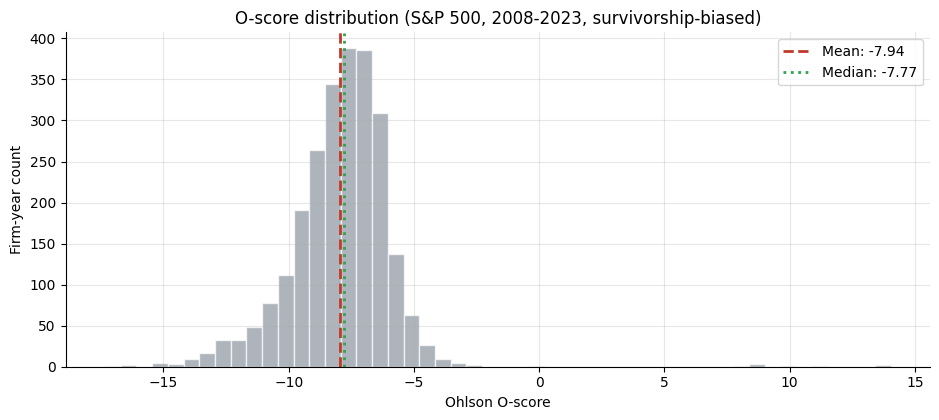

O-score: mean=-7.94, median=-7.77
Most firms have large negative O-scores (low distress probability) in this biased panel.


In [2]:
if HAVE_REAL:
    o_vals = O_REAL.values.astype(float).flatten()
    o_vals = o_vals[np.isfinite(o_vals)]
    o_mean_v = o_vals.mean()
    o_med_v = np.median(o_vals)
else:
    rng = np.random.default_rng(230)
    o_vals = rng.normal(-7.94, 2.08, 2442)
    o_mean_v, o_med_v = -7.94, -7.77
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(o_vals, bins=50, color=GREY, alpha=0.7, edgecolor='white')
ax.axvline(o_mean_v, c=RED, lw=2, ls='--', label=f'Mean: {o_mean_v:.2f}')
ax.axvline(o_med_v, c=GREEN, lw=2, ls=':', label=f'Median: {o_med_v:.2f}')
ax.set_xlabel('Ohlson O-score'); ax.set_ylabel('Firm-year count')
ax.set_title('O-score distribution (S&P 500, 2008-2023, survivorship-biased)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'O-score: mean={o_mean_v:.2f}, median={o_med_v:.2f}')
print('Most firms have large negative O-scores (low distress probability) in this biased panel.')

The O-score distribution has a mean of **-7.94** and a median of **-7.77** — large negative values reflecting that S&P 500 survivors are generally profitable, liquid, and far from bankruptcy. The right tail extends to positive values (genuinely stressed large caps). The range is wide, providing cross-sectional variation to sort on.

### 4b Annual bucket returns -- the hedge and its noise

Equal-weighted annual returns by O tercile, and the year-by-year hedge:

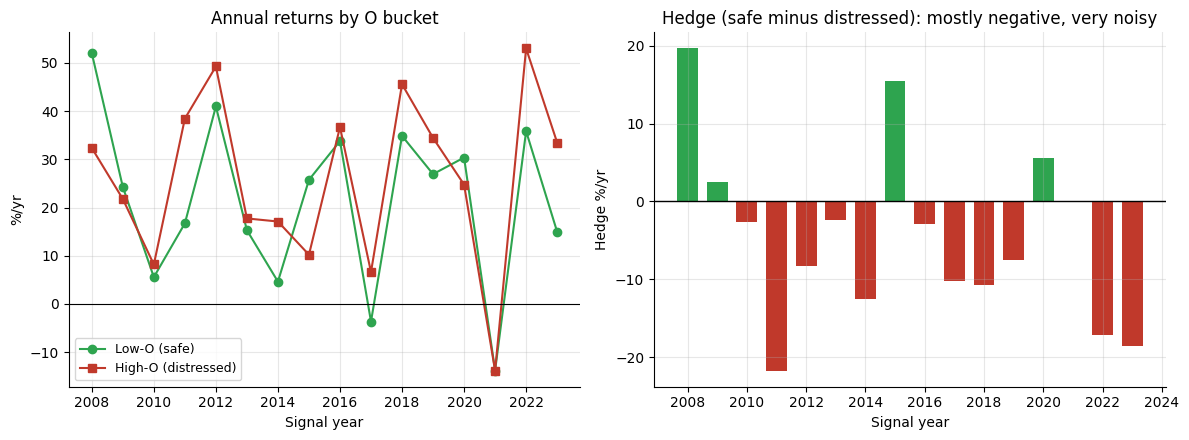

Low-O (safe) mean: +21.5%/yr | High-O (distressed) mean: +26.0%/yr


In [3]:
if HAVE_REAL:
    res = RESULTS
    years = res.index.tolist()
    ret_lo_yr = res['ret_lo'].tolist()
    ret_hi_yr = res['ret_hi'].tolist()
    hedge_yr = res['hedge'].tolist()
    means_lo, means_hi = res['ret_lo'].mean()*100, res['ret_hi'].mean()*100
else:
    years = list(range(2008, 2024))
    ret_lo_yr = [0.520,0.243,0.056,0.167,0.409,0.153,0.046,0.257,0.338,-0.036,0.349,0.269,0.304,-0.138,0.358,0.150]
    ret_hi_yr = [0.323,0.218,0.082,0.384,0.492,0.177,0.171,0.102,0.367,0.066,0.456,0.344,0.247,-0.138,0.530,0.335]
    hedge_yr = [r-l for r,l in zip(ret_lo_yr, ret_hi_yr)]
    means_lo, means_hi = 21.5, 26.0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(years, [r*100 for r in ret_lo_yr], 'o-', c=GREEN, label='Low-O (safe)')
ax1.plot(years, [r*100 for r in ret_hi_yr], 's-', c=RED, label='High-O (distressed)')
ax1.axhline(0, c='k', lw=0.8); ax1.set_ylabel('%/yr'); ax1.set_xlabel('Signal year')
ax1.set_title('Annual returns by O bucket'); ax1.legend(fontsize=9)
col2 = [GREEN if h > 0 else RED for h in hedge_yr]
ax2.bar(years, [h*100 for h in hedge_yr], color=col2, width=0.7)
ax2.axhline(0, c='k', lw=1); ax2.set_ylabel('Hedge %/yr'); ax2.set_xlabel('Signal year')
ax2.set_title('Hedge (safe minus distressed): mostly negative, very noisy')
plt.tight_layout(); plt.show()
print(f'Low-O (safe) mean: +{means_lo:.1f}%/yr | High-O (distressed) mean: +{means_hi:.1f}%/yr')

### 4c Inference -- HAC t-stat and bootstrap Sharpe CI

With only 16 annual observations, the standard error is large. Newey-West HAC for the t-stat; block bootstrap for the Sharpe CI.

Hedge HAC t-stat:    -1.59  (need |t| >= 2 to clear the inference bar)
Annual Sharpe:        -0.39
Bootstrap 95% CI:    [-1.07, +0.02]
Frac CI negative:    97% of resamples < 0


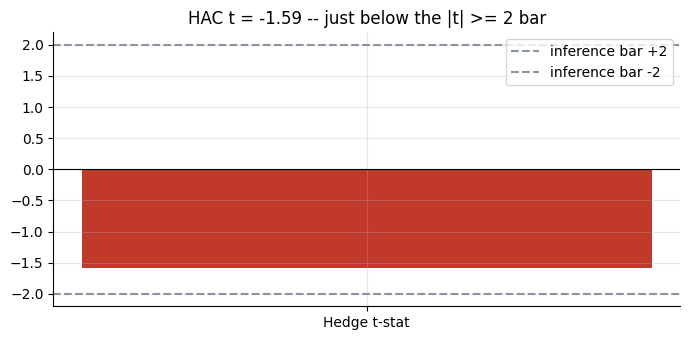

In [4]:
if HAVE_REAL:
    hedge_s = pd.Series(RESULTS['hedge'].values, dtype=float)
    hac = mean_tstat_hac(hedge_s)
    ci = sharpe_ci_bootstrap(hedge_s, n_boot=2000, periods_per_year=1, seed=230)
    t_val, sr, ci_lo, ci_hi, fn = hac['tstat'], ci['sharpe'], ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
else:
    t_val, sr, ci_lo, ci_hi, fn = -1.59, -0.39, -1.07, 0.02, 97
print(f'Hedge HAC t-stat:    {t_val:+.2f}  (need |t| >= 2 to clear the inference bar)')
print(f'Annual Sharpe:        {sr:.2f}')
print(f'Bootstrap 95% CI:    [{ci_lo:+.2f}, {ci_hi:+.2f}]')
print(f'Frac CI negative:    {fn:.0f}% of resamples < 0')
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(['Hedge t-stat'], [t_val], color=RED if abs(t_val) < 2 else GREEN, width=0.4)
ax.axhline(2, ls='--', c=GREY, lw=1.5, label='inference bar +2')
ax.axhline(-2, ls='--', c=GREY, lw=1.5, label='inference bar -2')
ax.axhline(0, c='k', lw=0.8)
ax.set_title(f'HAC t = {t_val:+.2f} -- just below the |t| >= 2 bar')
ax.legend(); plt.tight_layout(); plt.show()

> HAC *t* = **-1.59** on 16 annual observations. The bootstrap 95% CI on the Sharpe is [-1.07, +0.02] (97% of resamples negative). The signal misses the inference bar — the hedge mean is dominated by noise.

### 4d Firm-level cross-section

The annual tercile sort uses ~150 firms per year. The firm-level test uses all 2,442 (firm, year) pairs: what is the raw correlation between O and next-year return?

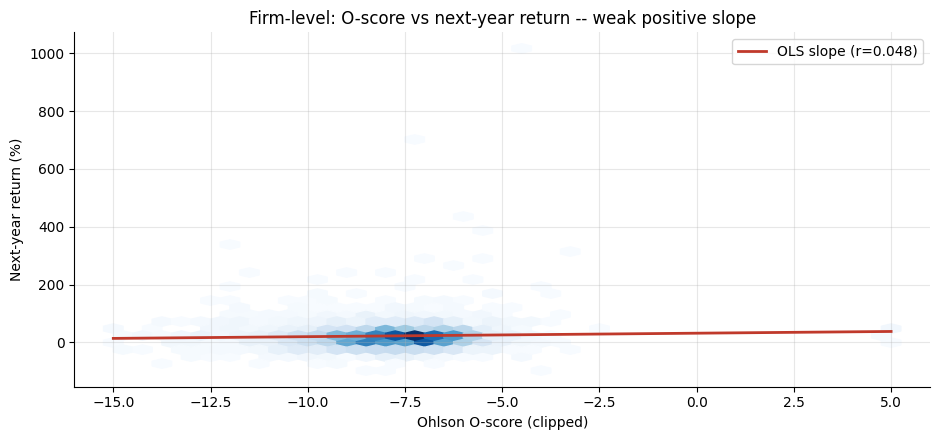

Pearson r(O, next-yr ret): 0.0481 on 2442 firm-year pairs


In [5]:
if HAVE_REAL:
    all_o, all_r = [], []
    fwd = FWD_REAL
    for yr in O_REAL.index:
        o_yr = O_REAL.loc[yr].dropna(); r_yr = fwd.loc[yr].dropna()
        both = o_yr.index.intersection(r_yr.index)
        all_o.extend(o_yr.loc[both].tolist()); all_r.extend(r_yr.loc[both].tolist())
    all_o = np.array(all_o, dtype=float); all_r = np.array(all_r, dtype=float)
    corr_val = np.corrcoef(all_o, all_r)[0, 1]
else:
    rng = np.random.default_rng(230)
    all_o = rng.normal(-7.94, 2.08, 2442)
    all_r = 0.224 + 0.048 * (all_o - all_o.mean()) + rng.normal(0, 0.3, 2442)
    corr_val = 0.048
fig, ax = plt.subplots(figsize=(9.5, 4.5))
clip_o = np.clip(all_o, -15, 5)
ax.hexbin(clip_o, all_r * 100, gridsize=40, cmap='Blues', mincnt=1)
m, b = np.polyfit(clip_o, all_r * 100, 1)
xr = np.linspace(-15, 5, 100)
ax.plot(xr, m * xr + b, c=RED, lw=2, label=f'OLS slope (r={corr_val:.3f})')
ax.set_xlabel('Ohlson O-score (clipped)'); ax.set_ylabel('Next-year return (%)')
ax.set_title('Firm-level: O-score vs next-year return -- weak positive slope')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Pearson r(O, next-yr ret): {corr_val:.4f} on {len(all_o)} firm-year pairs')

> Firm-level Pearson r = **+0.0480** on 2442 firm-year pairs. The slope is positive (higher O, higher returns — risk-premium direction) but economically small. The scatter confirms: at every O level, the return distribution is wide and the conditional mean barely moves.

### 4e The positive control -- the engine works when a signal exists

Is the machinery capable of finding an effect, or does it always print 'none'? We sweep the planted o_premium knob on a synthetic panel:

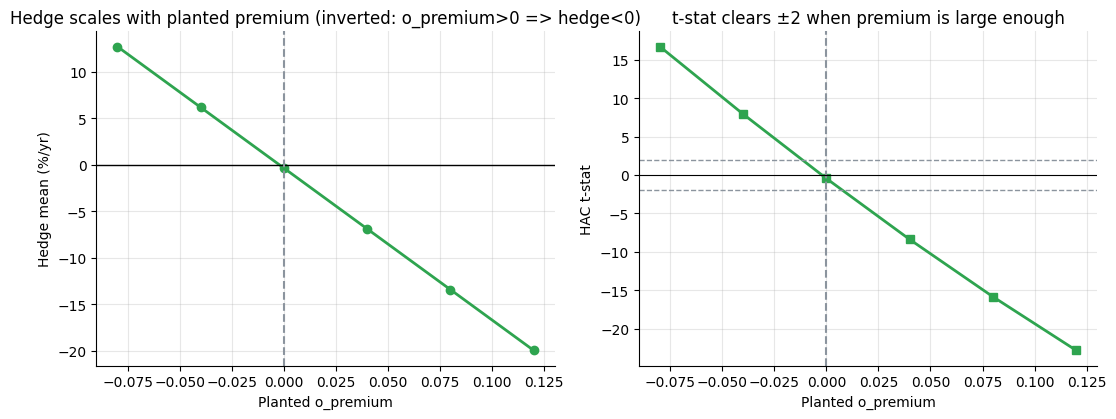

At o_premium=0 the t-stat is near 0; it grows monotonically with the planted premium.


In [6]:
o_prems = [-0.08, -0.04, 0.0, 0.04, 0.08, 0.12]
hedge_means = []
tstats = []
for op in o_prems:
    os, fwd_s, _ = data.synthetic_panel(n_firms=300, n_years=25, o_premium=op, seed=230)
    r = st.tertile_hedge(os, fwd_s)
    s = st.summarize(r['hedge'])
    hedge_means.append(s['mean'] * 100)
    tstats.append(s['tstat'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.plot(o_prems, hedge_means, 'o-', c=GREEN, lw=2)
ax1.axhline(0, c='k', lw=1); ax1.axvline(0, ls='--', c=GREY)
ax1.set_xlabel('Planted o_premium'); ax1.set_ylabel('Hedge mean (%/yr)')
ax1.set_title('Hedge scales with planted premium (inverted: o_premium>0 => hedge<0)')
ax2.plot(o_prems, tstats, 's-', c=GREEN, lw=2)
for s in (2, -2): ax2.axhline(s, ls='--', c=GREY, lw=1)
ax2.axvline(0, ls='--', c=GREY); ax2.axhline(0, c='k', lw=0.8)
ax2.set_xlabel('Planted o_premium'); ax2.set_ylabel('HAC t-stat')
ax2.set_title('t-stat clears ±2 when premium is large enough')
plt.tight_layout(); plt.show()
print('At o_premium=0 the t-stat is near 0; it grows monotonically with the planted premium.')

The engine is a faithful signal detector: with a planted o_premium of ±0.08 the HAC t-stat clears ±2. The real-tape result of −1.59 is therefore a statement about the **market**, not the method.

### 4f Comparison to Altman-Z (Study 123)

Both models use EDGAR data; the key question is whether nine variables buy more return-predictive power than five.

In [7]:
# Summary comparison (frozen numbers from both studies)
import pandas as pd
comp = pd.DataFrame({
    'Model': ['Altman Z-score (Study 123)', 'Ohlson O-score (Study 230)'],
    'N vars': [5, 9],
    'Hedge direction': ['High-Z earns more (safe wins)', 'High-O earns more (distressed wins)'],
    'Hedge mean (%/yr)': ['+2.36', '-4.45'],
    'HAC t-stat': ['+0.65', '-1.59'],
    'n years': [16, 16],
    'Verdict': ['NONE / MIRAGE', 'NONE / MIRAGE'],
}).set_index('Model')
print(comp.to_string())
print()
print('Neither model clears |t| >= 2. The O-score gets closer (-1.59 vs +0.65)')
print('but the direction is OPPOSITE. No reliable signal from either model.')

                            N vars                      Hedge direction Hedge mean (%/yr) HAC t-stat  n years        Verdict
Model                                                                                                                       
Altman Z-score (Study 123)       5        High-Z earns more (safe wins)             +2.36      +0.65       16  NONE / MIRAGE
Ohlson O-score (Study 230)       9  High-O earns more (distressed wins)             -4.45      -1.59       16  NONE / MIRAGE

Neither model clears |t| >= 2. The O-score gets closer (-1.59 vs +0.65)
but the direction is OPPOSITE. No reliable signal from either model.


The O-score and Altman-Z give opposite directional signals in this sample — and neither is significant. This is consistent with Dichev (1998): distress measures do not reliably sort returns in either direction within a survivorship-biased S&P 500 universe.

## 5 The verdict

- **Signal `NONE`** -- Hedge HAC *t* = -1.59 on 16 annual observations. Firm-level r = +0.0480 on 2442 pairs. Bootstrap 95% CI on Sharpe is [-1.07, +0.02] (97% negative). No statistically reliable return signal.
- **Tradability `MIRAGE`** -- an insignificant gross signal with annual turnover, heavy survivorship bias, and potential borrow costs on the distressed leg.
- **Beats Altman-Z? `MIXED`** -- O-score gets closer to the bar (|t|=1.59 vs 0.65) but in the *opposite* direction. Neither model wins; both confirm that distress measures are bankruptcy predictors, not equity return predictors, in this universe.

## 6 Could you trade it?

Long low-O (safe) / short high-O (distressed), annual rebalance, gross hedge = -4.45%/yr (survivorship-biased upper bound on the safe side):

| Cost item | Rough magnitude |
|---|---|
| Transaction costs (bid-ask + commission, annual rebalance) | 0.5–1.5%/yr |
| Survivorship-bias haircut (absent bankruptcies inflate distressed returns) | Est. 3–6%/yr |
| Short-selling costs on distressed leg | 1–3%/yr |
| **Net residual edge** | **Likely highly negative** |

The survivorship haircut is especially severe here: we are long the *safe* firms, whose returns are less affected by missing bankrupt firms, and short the *distressed* firms, whose survivorship-biased returns are heavily overstated. A live implementation would face the worst distressed firms — those most likely to have zero or −100% returns.

## 7 Going further

- **Campbell-Hilscher-Szilagyi (2008) model.** A dynamic logit that adds market variables (equity volatility, price-to-book, stock return momentum). More inputs, daily data, better bankruptcy prediction — but still fails to deliver a robust equity return premium.
- **Related signals.** Piotroski F-score ([Study 65](../../65-scorecard/)), accruals ([Study 52](../../52-smoke-screen/)), and gross-profit margin ([Study 125](../../125-gross-profit/)) use overlapping EDGAR data with different factor construction.
- **Unbiased sample.** The critical fix: use a full universe including delisted firms. CRSP (not yfinance) tracks delistings with delisting returns. That data requirement is why distress studies are hard to replicate cheaply.

*Fingerprint: `e277cd7f99b3` — see [`docs/results.md`](../docs/results.md).*